## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Practice for using `polyfit()` and `curve_fit()`

Includes practice for:
- load basic data
- numpy arrays
- fitting

Goal: Help students prepare for quiz 4b


### How many births in the US?

The following dataset was used as the basis for the story [Some People Are Too Superstitious To Have A Baby On Friday The 13th](https://fivethirtyeight.com/features/some-people-are-too-superstitious-to-have-a-baby-on-friday-the-13th/) and is available at [Fivethirtyeight](https://github.com/fivethirtyeight/data)  (a great resource for your semester project data).

&#9989;&nbsp; Load the data from `US_births_2000-2014_SSA.csv` into your notebook **using Pandas** and then use Pandas to display the first 10 rows of the data.

In [196]:
### ANSWER ####
import pandas as pd

bb = pd.read_csv("US_births_2000-2014_SSA.csv")  # 2 pts
bb.head(10)  # 2 pts

,year,month,date_of_month,day_of_week,births
0,2000,1,1,6,9083
1,2000,1,2,7,8006
2,2000,1,3,1,11363
3,2000,1,4,2,13032
4,2000,1,5,3,12558
5,2000,1,6,4,12466
6,2000,1,7,5,12516
7,2000,1,8,6,8934
8,2000,1,9,7,7949
9,2000,1,10,1,11668


&#9989;&nbsp; Let's try to answer the question:

**PART 1: Did the number of births increase during the year 2000?** (In other words, as the year 2000 progressed, were there more births at the end of the year compared to the beginning (on average))

In [197]:
# Make a plot of the number of births versus day for just the year 2000


# Fit a model (polynomial or arbitrary curve) to this data


# Display original data and fitted model


# What is the equation of the fitted model?

# Make a conclusion about how the births have changed throughout the year

y =  1.5010130022866741 * x +  11063.764580634592


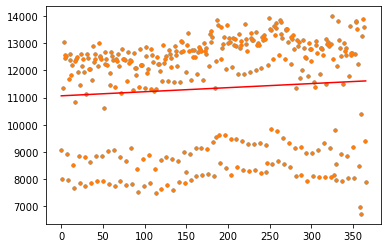

In [120]:
### ANSWER ####

# Make a plot of the number of births versus day for just the year 2000
import matplotlib.pyplot as plt
%matplotlib inline
b2 = bb[bb['year']==2000]
x = np.arange(0,366,1)
plt.plot(x,b2['births'],'.')

# Fit a model (polynomial or arbitrary curve) to this data
import numpy as np
y = b2['births']
f1 = np.polyfit(x,y,1)
ff1 = np.poly1d(f1)


# Display original data and fitted model
plt.plot(x,b2['births'],'.')
plt.plot(x,ff1(x),'r-')


# Make a conclusion about how the births have changed throughout the year
print('y = ', f1[0],'* x + ',f1[1] )
# increased 1.5 births per day

&#9989;&nbsp; Let's try to answer the question:

**PART 2: what is a good function that fits the number of births in January 2000?** 

In [198]:
# Make a plot of the number of births versus day for just January 2000
b2 = bb[bb['year']==2000]
b2Jan = b2[b2['month']==1]  # b2Jan is a pandas dataframe of just Jan 2000

# Fit the following arbitrary function to the births in jan 2000
def sin1(x,A,B,C):
    y1 = A*np.sin(B*x*2*np.pi)+C
    return y1

# If trouble fitting data, try initializing with A = -4000; B = 1/7; C = 9000


# Display original data and fitted model


# What is the equation of the fitted model? (Write out the equation)



# Make a conclusion about how the births have changed in january 2000

The best parameters are  [-1.99135160e+03  1.50399360e-01  1.10178954e+04]


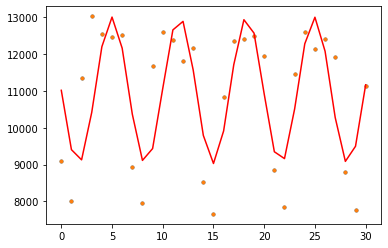

In [195]:
### ANSWER ####

# Make a plot of the number of births versus day for just the year 2000
import matplotlib.pyplot as plt
%matplotlib inline
b2 = bb[bb['year']==2000]
b2Jan = b2[b2['month']<2]

x = np.arange(0,b2Jan.shape[0],1)

y = b2Jan['births']
plt.plot(x,y,'.')

# Fit a model (polynomial or arbitrary curve) to this data
def sin1(x,A,B,C):
    y1 = A*np.sin(B*x*2*np.pi)+C
    return y1

from scipy.optimize import curve_fit

popt, pcov = curve_fit(sin1, x, y,p0 = [-4000,1/7, 9000])
print('The best parameters are ', popt)


# Display original data and fitted model
plt.plot(x,y,'.')
plt.plot(x,sin1(x,popt[0],popt[1],popt[2]),'r-')




# Make a conclusion about how the births have changed in jan 2000
# Number of births oscillates with each week (frequency)


----------------
&#9989;&nbsp; Let's try to answer the question:

**PART 3: Based on all of the data from 2000-2014, predict the number of births on April 23, 2021 (the last day of this semester) ?  And, predict the total number of births in the year 2021?** 

In [ ]:
### ANSWER ####

#The key here is getting appropriate x-values. Specifically, getting x_max. There are a few ways to do this.

#One is to use the datetime package
from datetime import date

d0 = date(2000, 1, 1)
d1 = date(2021, 4, 23)
delta = d1 - d0
print(delta.days)

#You can also look up the difference in days using a website like this 
#https://www.timeanddate.com/date/duration.html

#We get the same answer from both of these methods: the number of days between 1/1/2000 and 4/23/2021 is 7783
#With this in hand, here is the rest of the solution.

x_days = bb.index           #Index corresponds to the number of days past 1/1/2000
y_births = bb["births"]

birth_fit_vals = np.polyfit(x_days, y_births, 1)
birth_fit_func = np.poly1d(birth_fit_vals)

x_fit_max = 7783
print(f"The predicted number of births on April 23, 2021 is {int(birth_fit_func(x_fit_max))}")

In [ ]:
### ANSWER ####

#To get the total number of births for the year 2021, we need to know x at the start of 2021 and x at the end of 2021

from datetime import date

d2 = date(2000, 1, 1)
d3 = date(2021, 1, 1)
delta2 = d3 - d2
print(delta2.days)

x_2021_vals = np.arange(delta2.days, delta2.days+365)
y_2021_fit_vals = birth_fit_func(x_2021_vals)
print(f"The total predicted number of births in 2021 is {int(np.sum(y_2021_fit_vals))}")

&#169; Copyright 2021,  Michigan State University Board of Trustees